In [1]:
using Symbolics, OffsetArrays
using SymbolicUtils
using LinearAlgebra


In [2]:
@variables A[1:1,0:2] B[1:1,0:2] C[1:1,0:2] D[1:1,0:2] a[1:1] c[1:1] w[0:2] u[0:2]

8-element Vector{Symbolics.Arr{Num}}:
 A[1:1,0:2]
 B[1:1,0:2]
 C[1:1,0:2]
 D[1:1,0:2]
 a[1:1]
 c[1:1]
 w[0:2]
 u[0:2]

In [3]:
eq1 = dot(A,u) + dot(B,w) ~ a[1]
eq2 = dot(C,u) + dot(D,w) ~ c[1]

C[1, 0]*u[0] + C[1, 1]*u[1] + C[1, 2]*u[2] + D[1, 0]*w[0] + D[1, 1]*w[1] + D[1, 2]*w[2] ~ c[1]

In [4]:
eqs = [eq1, eq2]
sol = solve_for(eqs,[u[0], w[0]])

2-element Vector{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}:
 (-a[1] + (B[1, 0]*(-c[1] + (-(-a[1] + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2])*C[1, 0]) / A[1, 0] + C[1, 1]*u[1] + C[1, 2]*u[2] + D[1, 1]*w[1] + D[1, 2]*w[2])) / (-D[1, 0] + (B[1, 0]*C[1, 0]) / A[1, 0]) + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2]) / (-A[1, 0])
 (-c[1] + (-(-a[1] + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2])*C[1, 0]) / A[1, 0] + C[1, 1]*u[1] + C[1, 2]*u[2] + D[1, 1]*w[1] + D[1, 2]*w[2]) / (-D[1, 0] + (B[1, 0]*C[1, 0]) / A[1, 0])

In [6]:
@variables dx Kbar[0:1] Fmid[0:1] Gmid[0:1] dt F[1:1] G[1:1] Fx[1:1] Gx[1:1] w_old[0:2]

# we take the discretized eqs for the internal points and copy last known point for 
# Kbar, F, G to the midpoint 1/2 (for i=0), copied that from 3/2 (for i=1, that is the 1st point)
# and the same for w_old[0] from w_old[1]

subs_i1_step1 = Dict(
    # 1st eq
    A[1,0] => Kbar[0]/dx^2,
    A[1,1] => -(Kbar[1]+Kbar[0])/dx^2,
    A[1,2] => Kbar[1]/dx^2,
    B[1,0] => -Kbar[0]/dx^2,
    B[1,1] => (Kbar[1]+Kbar[0])/dx^2,
    B[1,2] => -Kbar[1]/dx^2,
    a[1]=>0,
    # 2nd eq
    C[1,0] => dt*Fmid[0]*Gmid[0]/2,
    C[1,1] => -dt*(Fmid[1]*Gmid[1]/2-Fmid[0]*Gmid[0]/2-dx*(Fx[1]*G[1]+F[1]*Gx[1])),
    C[1,2] => -dt*Fmid[1]*Gmid[1]/2,
    D[1,0] => -(1+dt*Fmid[0]*Gmid[0])/2,
    D[1,1] => dt*(Fmid[1]*Gmid[1]/2-Fmid[0]*Gmid[0]/2-dx*(Fx[1]*G[1]+F[1]*Gx[1])),
    D[1,2] => (1+dt*Fmid[1]*Gmid[1])/2,
    c[1] => (w_old[2] - w_old[0])/2  
)

Dict{Num, Real} with 14 entries:
  a[1]    => 0
  D[1, 2] => (1 + Fmid[1]*Gmid[1]*dt) / 2
  A[1, 1] => (-Kbar[0] - Kbar[1]) / (dx^2)
  C[1, 1] => -(-(1//2)*Fmid[0]*Gmid[0] + (1//2)*Fmid[1]*Gmid[1] - (F[1]*Gx[1] +…
  c[1]    => (-w_old[0] + w_old[2]) / 2
  B[1, 1] => (Kbar[0] + Kbar[1]) / (dx^2)
  B[1, 2] => (-Kbar[1]) / (dx^2)
  D[1, 1] => (-(1//2)*Fmid[0]*Gmid[0] + (1//2)*Fmid[1]*Gmid[1] - (F[1]*Gx[1] + …
  C[1, 0] => (1//2)*Fmid[0]*Gmid[0]*dt
  A[1, 0] => Kbar[0] / (dx^2)
  D[1, 0] => (-1 - Fmid[0]*Gmid[0]*dt) / 2
  A[1, 2] => Kbar[1] / (dx^2)
  C[1, 2] => (-1//2)*Fmid[1]*Gmid[1]*dt
  B[1, 0] => (-Kbar[0]) / (dx^2)

In [7]:
subs_i1_step2 = Dict(
    Fmid[0] => Fmid[1],
    Gmid[0] => Gmid[1],
    Kbar[0] => Kbar[1],
    w_old[0] => w_old[1]
)

Dict{Num, Num} with 4 entries:
  Gmid[0]  => Gmid[1]
  w_old[0] => w_old[1]
  Kbar[0]  => Kbar[1]
  Fmid[0]  => Fmid[1]

In [8]:
sol1 = substitute(sol, subs_i1_step1)
sol2 = substitute(sol1, subs_i1_step2)

2-element Vector{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}:
 (-(dx^2)*((-2Kbar[1]*u[1]) / (dx^2) + (-Kbar[1]*w[2]) / (dx^2) + (2Kbar[1]*w[1]) / (dx^2) + (-((w_old[1] - w_old[2]) / 2 + ((-1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((-2Kbar[1]*u[1]) / (dx^2) + (-Kbar[1]*w[2]) / (dx^2) + (2Kbar[1]*w[1]) / (dx^2) + (Kbar[1]*u[2]) / (dx^2))) / Kbar[1] - (1//2)*Fmid[1]*Gmid[1]*dt*u[2] + (1//2)*(1 + Fmid[1]*Gmid[1]*dt)*w[2] + (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*u[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*w[1])*Kbar[1]) / ((-(1//2)*Fmid[1]*Gmid[1]*dt + (1 + Fmid[1]*Gmid[1]*dt) / 2)*(dx^2)) + (Kbar[1]*u[2]) / (dx^2))) / Kbar[1]
 ((w_old[1] - w_old[2]) / 2 + ((-1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((-2Kbar[1]*u[1]) / (dx^2) + (-Kbar[1]*w[2]) / (dx^2) + (2Kbar[1]*w[1]) / (dx^2) + (Kbar[1]*u[2]) / (dx^2))) / Kbar[1] - (1//2)*Fmid[1]*Gmid[1]*dt*u[2] + (1//2)*(1 + Fmid[1]*Gmid[1]*dt)*w[2] + (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*u[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*w[1]) / (-(1//2)*Fmid[1]*Gmid[1]*

In [9]:
eq2b = substitute(eq2, Dict( u[0] => sol[1], w[0] => sol[2]))

((-c[1] + (-(-a[1] + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2])*C[1, 0]) / A[1, 0] + C[1, 1]*u[1] + C[1, 2]*u[2] + D[1, 1]*w[1] + D[1, 2]*w[2])*D[1, 0]) / (-D[1, 0] + (B[1, 0]*C[1, 0]) / A[1, 0]) + (-(-a[1] + (B[1, 0]*(-c[1] + (-(-a[1] + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2])*C[1, 0]) / A[1, 0] + C[1, 1]*u[1] + C[1, 2]*u[2] + D[1, 1]*w[1] + D[1, 2]*w[2])) / (-D[1, 0] + (B[1, 0]*C[1, 0]) / A[1, 0]) + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2])*C[1, 0]) / A[1, 0] + C[1, 1]*u[1] + C[1, 2]*u[2] + D[1, 1]*w[1] + D[1, 2]*w[2] ~ c[1]

In [44]:
eq2c = substitute(eq2b, subs_i1_step1)
eq2d = substitute(eq2c, subs_i1_step2)

@variables ubarL
eq2d = substitute(eq2d, u[1]=>ubarL)


((-1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((-Kbar[1]*w[2]) / (dx^2) + (-((w_old[1] - w_old[2]) / 2 + ((-1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((-Kbar[1]*w[2]) / (dx^2) + (2Kbar[1]*w[1]) / (dx^2) + (-2Kbar[1]*ubarL) / (dx^2) + (Kbar[1]*u[2]) / (dx^2))) / Kbar[1] - (1//2)*Fmid[1]*Gmid[1]*dt*u[2] + (1//2)*(1 + Fmid[1]*Gmid[1]*dt)*w[2] + (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*ubarL - (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*w[1])*Kbar[1]) / ((-(1//2)*Fmid[1]*Gmid[1]*dt + (1 + Fmid[1]*Gmid[1]*dt) / 2)*(dx^2)) + (2Kbar[1]*w[1]) / (dx^2) + (-2Kbar[1]*ubarL) / (dx^2) + (Kbar[1]*u[2]) / (dx^2))) / Kbar[1] + ((1//2)*((w_old[1] - w_old[2]) / 2 + ((-1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((-Kbar[1]*w[2]) / (dx^2) + (2Kbar[1]*w[1]) / (dx^2) + (-2Kbar[1]*ubarL) / (dx^2) + (Kbar[1]*u[2]) / (dx^2))) / Kbar[1] - (1//2)*Fmid[1]*Gmid[1]*dt*u[2] + (1//2)*(1 + Fmid[1]*Gmid[1]*dt)*w[2] + (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*ubarL - (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*w[1])*(-1 - Fmid[1]*Gmid[1]*dt)) / (-(1//2)*Fmid[1]*Gmid[1]*dt + (1 + Fmid[1]*Gmid[1]

In [45]:
expr = expand(eq2d.lhs - eq2d.rhs)

(1//2)*w[2] + (1//2)*w_old[1] - (1//2)*w_old[2] + (-(1//2)*Fmid[1]*Gmid[1]*Kbar[1]*dt*u[2] + Fmid[1]*Gmid[1]*Kbar[1]*dt*ubarL - Fmid[1]*Gmid[1]*Kbar[1]*dt*w[1] + (1//2)*Fmid[1]*Gmid[1]*Kbar[1]*dt*w[2] - (-(1//2)*Kbar[1]*w[2] - (1//2)*Kbar[1]*w_old[1] + (1//2)*Kbar[1]*w_old[2] + Fmid[1]*Gmid[1]*Kbar[1]*dt*u[2] - Fmid[1]*Gmid[1]*Kbar[1]*dt*ubarL + Fmid[1]*Gmid[1]*Kbar[1]*dt*w[1] - Fmid[1]*Gmid[1]*Kbar[1]*dt*w[2] - F[1]*Gx[1]*Kbar[1]*dt*dx*ubarL + F[1]*Gx[1]*Kbar[1]*dt*dx*w[1] - Fx[1]*G[1]*Kbar[1]*dt*dx*ubarL + Fx[1]*G[1]*Kbar[1]*dt*dx*w[1])*Fmid[1]*Gmid[1]*dt) / Kbar[1] - (1//2)*Fmid[1]*Gmid[1]*dt*u[2] + (1//2)*Fmid[1]*Gmid[1]*dt*w[2] + F[1]*Gx[1]*dt*dx*ubarL - F[1]*Gx[1]*dt*dx*w[1] + Fx[1]*G[1]*dt*dx*ubarL - Fx[1]*G[1]*dt*dx*w[1] + (-(1//4)*w[2] - (1//4)*w_old[1] + (1//4)*w_old[2] + ((-1//2)*(-(1//2)*Fmid[1]*Gmid[1]*Kbar[1]*dt*u[2] + Fmid[1]*Gmid[1]*Kbar[1]*dt*ubarL - Fmid[1]*Gmid[1]*Kbar[1]*dt*w[1] + (1//2)*Fmid[1]*Gmid[1]*Kbar[1]*dt*w[2])) / Kbar[1] + ((-1//2)*Fmid[1]*(-(1//2)*Fmid[1]

In [46]:
# copied from https://discourse.julialang.org/t/help-with-symbolics-how-to-get-coefficients-and-simple-roots/68180/3
function mycoeffs(f,var,order)
    if order == 0
        return substitute(f,Dict(var=>0))
    end
    D=Differential(var^order)
    newf=expand_derivatives(D(f))
    return substitute(newf,Dict(var=>0))
end

mycoeffs (generic function with 1 method)

In [48]:
w1_coeff = simplify(mycoeffs(expr, w[1],1))

0

In [49]:
w2_coeff = simplify(mycoeffs(expr, w[2],1))

0

In [50]:
u1_coeff = simplify(mycoeffs(expr, u[1],1))

0

In [51]:
u2_coeff = simplify(mycoeffs(expr, u[2],1))

0

In [52]:
simplify(substitute(expr, Dict(u[1]=>0,u[2]=>0,w[1]=>0,w[2]=>0)))

0

In [53]:
wx_1 = (w[2]-w[0])/(2*dx)

(-w[0] + w[2]) / (2dx)

In [54]:
wx_1_b = substitute(wx_1, w[0]=>sol[2])

(w[2] + (c[1] - ((-(-a[1] + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 1]*w[1] + B[1, 2]*w[2])*C[1, 0]) / A[1, 0]) - C[1, 1]*u[1] - C[1, 2]*u[2] - D[1, 1]*w[1] - D[1, 2]*w[2]) / (-D[1, 0] + (B[1, 0]*C[1, 0]) / A[1, 0])) / (2dx)

In [55]:
wx_1_c = substitute(wx_1_b, subs_i1_step1)

(w[2] + ((-w_old[0] + w_old[2]) / 2 + ((1//2)*Fmid[0]*Gmid[0]*dt*(dx^2)*((-Kbar[1]*w[2]) / (dx^2) + (Kbar[1]*u[2]) / (dx^2) + ((-Kbar[0] - Kbar[1])*u[1]) / (dx^2) + ((Kbar[0] + Kbar[1])*w[1]) / (dx^2))) / Kbar[0] + (1//2)*Fmid[1]*Gmid[1]*dt*u[2] - (1//2)*(1 + Fmid[1]*Gmid[1]*dt)*w[2] + (-(1//2)*Fmid[0]*Gmid[0] + (1//2)*Fmid[1]*Gmid[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dx)*dt*u[1] - (-(1//2)*Fmid[0]*Gmid[0] + (1//2)*Fmid[1]*Gmid[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dx)*dt*w[1]) / (-(1//2)*Fmid[0]*Gmid[0]*dt + (1 + Fmid[0]*Gmid[0]*dt) / 2)) / (2dx)

In [57]:
wx_1_c = expand(substitute(wx_1_c, subs_i1_step2))
wx_1_c = substitute(wx_1_c, u[1]=>ubarL)

(-w_old[1] + w_old[2] + ((2//1)*((1//2)*Fmid[1]*Gmid[1]*Kbar[1]*dt*u[2] - Fmid[1]*Gmid[1]*Kbar[1]*dt*ubarL + Fmid[1]*Gmid[1]*Kbar[1]*dt*w[1] - (1//2)*Fmid[1]*Gmid[1]*Kbar[1]*dt*w[2])) / Kbar[1] + Fmid[1]*Gmid[1]*dt*u[2] - Fmid[1]*Gmid[1]*dt*w[2] - (2//1)*F[1]*Gx[1]*dt*dx*ubarL + (2//1)*F[1]*Gx[1]*dt*dx*w[1] - (2//1)*Fx[1]*G[1]*dt*dx*ubarL + (2//1)*Fx[1]*G[1]*dt*dx*w[1]) / (2dx)

In [58]:
wx_1_c_w1_coeff = simplify(mycoeffs(wx_1_c, w[1],1))

(Fmid[1]*Gmid[1]*dt + F[1]*Gx[1]*dt*dx + Fx[1]*G[1]*dt*dx) / dx

In [59]:
wx_1_c_w2_coeff = simplify(mycoeffs(wx_1_c, w[2],1))

(-Fmid[1]*Gmid[1]*dt) / dx

In [60]:
wx_1_c_u1_coeff = simplify(mycoeffs(wx_1_c, u[1],1))

0

In [61]:
wx_1_c_u2_coeff = simplify(mycoeffs(wx_1_c, u[2],1))

(Fmid[1]*Gmid[1]*dt) / dx

In [65]:
the_rest_lhs = simplify(substitute(wx_1_c, Dict(w[1]=>0, w[2]=>0, u[2]=>0)))
print(-the_rest_lhs)

(w_old[1] - w_old[2] + (2//1)*Fmid[1]*Gmid[1]*dt*ubarL + (2//1)*F[1]*Gx[1]*dt*dx*ubarL + (2//1)*Fx[1]*G[1]*dt*dx*ubarL) / (2dx)

In [29]:
"""
    for i=N we cannot use N explicitly as an index, so we use the expressions from before
    and assume that N=2 and solve for that
"""

"    for i=N we cannot use N explicitly as an index, so we use the expressions from before\n    and assume that N=2 and solve for that\n"

In [30]:
solN = solve_for(eqs,[u[2], w[2]])

2-element Vector{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}:
 (-a[1] + (B[1, 2]*(-c[1] + (-(-a[1] + A[1, 0]*u[0] + A[1, 1]*u[1] + B[1, 0]*w[0] + B[1, 1]*w[1])*C[1, 2]) / A[1, 2] + C[1, 0]*u[0] + C[1, 1]*u[1] + D[1, 0]*w[0] + D[1, 1]*w[1])) / (-D[1, 2] + (B[1, 2]*C[1, 2]) / A[1, 2]) + A[1, 0]*u[0] + A[1, 1]*u[1] + B[1, 0]*w[0] + B[1, 1]*w[1]) / (-A[1, 2])
 (-c[1] + (-(-a[1] + A[1, 0]*u[0] + A[1, 1]*u[1] + B[1, 0]*w[0] + B[1, 1]*w[1])*C[1, 2]) / A[1, 2] + C[1, 0]*u[0] + C[1, 1]*u[1] + D[1, 0]*w[0] + D[1, 1]*w[1]) / (-D[1, 2] + (B[1, 2]*C[1, 2]) / A[1, 2])

In [32]:
# the map is 0,1,2 -> N-1, N, N+1, with N+1 outside on the right (ghost)
# for the midpoints for i=1 we had e.g. Fmid[0] on the left of i=1
# here we have Fmid[1] on the right of i=N, so we copy Fmid[1] from Fmid[0]
# for w_old[2] is copied from w_old[1]
subs_iN_step2 = Dict(
    Fmid[1] => Fmid[0],
    Gmid[1] => Gmid[0],
    Kbar[1] => Kbar[0],
    w_old[2] => w_old[1]
)

Dict{Num, Num} with 4 entries:
  Gmid[1]  => Gmid[0]
  Kbar[1]  => Kbar[0]
  Fmid[1]  => Fmid[0]
  w_old[2] => w_old[1]

In [37]:
wx_N = (w[2]-w[0])/(2*dx)
wx_N_b = substitute(wx_N, w[2]=>solN[2])
wx_N_c = substitute(wx_N_b, subs_i1_step1)
wx_N_c = expand(substitute(wx_N_c, subs_iN_step2))

(-w[0] + (-(1//2)*w[0] + (1//2)*w_old[0] - (1//2)*w_old[1] + ((1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*u[0] - Fmid[0]*Gmid[0]*Kbar[0]*dt*u[1] - (1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*w[0] + Fmid[0]*Gmid[0]*Kbar[0]*dt*w[1]) / Kbar[0] + (1//2)*Fmid[0]*Gmid[0]*dt*u[0] - (1//2)*Fmid[0]*Gmid[0]*dt*w[0] + F[1]*Gx[1]*dt*dx*u[1] - F[1]*Gx[1]*dt*dx*w[1] + Fx[1]*G[1]*dt*dx*u[1] - Fx[1]*G[1]*dt*dx*w[1]) / (-1//2)) / (2dx)

In [42]:
wx_N_c_u0_coeff = simplify(mycoeffs(wx_N_c, u[0],1))
print(wx_N_c_u0_coeff)

(-Fmid[0]*Gmid[0]*dt) / dx

In [41]:
wx_N_c_u1_coeff = simplify(mycoeffs(wx_N_c, u[1],1))
print(wx_N_c_u1_coeff)

(-Fmid[0]*Gmid[0]*dt + F[1]*Gx[1]*dt*dx + Fx[1]*G[1]*dt*dx) / (-dx)

In [39]:
wx_N_c_w0_coeff = simplify(mycoeffs(wx_N_c, w[0],1))
print(wx_N_c_w0_coeff)

(Fmid[0]*Gmid[0]*dt) / dx

In [40]:
wx_N_c_w1_coeff = simplify(mycoeffs(wx_N_c, w[1],1))
print(wx_N_c_w1_coeff)

(Fmid[0]*Gmid[0]*dt - F[1]*Gx[1]*dt*dx - Fx[1]*G[1]*dt*dx) / (-dx)

In [68]:
substitute(eq2.rhs, subs_i1_step1)

(-w_old[0] + w_old[2]) / 2

In [71]:
eq2_lhs_a = substitute(eq2.lhs, Dict(u[2]=>solN[1],w[2]=>solN[2]))

((-c[1] + (-(-a[1] + A[1, 0]*u[0] + A[1, 1]*u[1] + B[1, 0]*w[0] + B[1, 1]*w[1])*C[1, 2]) / A[1, 2] + C[1, 0]*u[0] + C[1, 1]*u[1] + D[1, 0]*w[0] + D[1, 1]*w[1])*D[1, 2]) / (-D[1, 2] + (B[1, 2]*C[1, 2]) / A[1, 2]) + (-(-a[1] + (B[1, 2]*(-c[1] + (-(-a[1] + A[1, 0]*u[0] + A[1, 1]*u[1] + B[1, 0]*w[0] + B[1, 1]*w[1])*C[1, 2]) / A[1, 2] + C[1, 0]*u[0] + C[1, 1]*u[1] + D[1, 0]*w[0] + D[1, 1]*w[1])) / (-D[1, 2] + (B[1, 2]*C[1, 2]) / A[1, 2]) + A[1, 0]*u[0] + A[1, 1]*u[1] + B[1, 0]*w[0] + B[1, 1]*w[1])*C[1, 2]) / A[1, 2] + C[1, 0]*u[0] + C[1, 1]*u[1] + D[1, 0]*w[0] + D[1, 1]*w[1]

In [73]:
eq2_lhs_b = substitute(eq2_lhs_a, subs_i1_step1)

((1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((Kbar[0]*u[0]) / (dx^2) + (-((w_old[0] - w_old[2]) / 2 + ((1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((Kbar[0]*u[0]) / (dx^2) + ((-Kbar[0] - Kbar[1])*u[1]) / (dx^2) + ((Kbar[0] + Kbar[1])*w[1]) / (dx^2) + (-Kbar[0]*w[0]) / (dx^2))) / Kbar[1] + (1//2)*Fmid[0]*Gmid[0]*dt*u[0] + (1//2)*(-1 - Fmid[0]*Gmid[0]*dt)*w[0] - (-(1//2)*Fmid[0]*Gmid[0] + (1//2)*Fmid[1]*Gmid[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dx)*dt*u[1] + (-(1//2)*Fmid[0]*Gmid[0] + (1//2)*Fmid[1]*Gmid[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dx)*dt*w[1])*Kbar[1]) / (((1//2)*Fmid[1]*Gmid[1]*dt + (-1 - Fmid[1]*Gmid[1]*dt) / 2)*(dx^2)) + ((-Kbar[0] - Kbar[1])*u[1]) / (dx^2) + ((Kbar[0] + Kbar[1])*w[1]) / (dx^2) + (-Kbar[0]*w[0]) / (dx^2))) / Kbar[1] + ((1//2)*((w_old[0] - w_old[2]) / 2 + ((1//2)*Fmid[1]*Gmid[1]*dt*(dx^2)*((Kbar[0]*u[0]) / (dx^2) + ((-Kbar[0] - Kbar[1])*u[1]) / (dx^2) + ((Kbar[0] + Kbar[1])*w[1]) / (dx^2) + (-Kbar[0]*w[0]) / (dx^2))) / Kbar[1] + (1//2)*Fmid[0]*Gmid[0]*dt*u[0] + (1//2)*(-1 - Fmid[0]*Gmid[0]*d

In [74]:
eq2_lhs_c = substitute(eq2_lhs_b, subs_iN_step2)

((1//2)*Fmid[0]*Gmid[0]*dt*(dx^2)*((-((w_old[0] - w_old[1]) / 2 + ((1//2)*Fmid[0]*Gmid[0]*dt*(dx^2)*((2Kbar[0]*w[1]) / (dx^2) + (Kbar[0]*u[0]) / (dx^2) + (-2Kbar[0]*u[1]) / (dx^2) + (-Kbar[0]*w[0]) / (dx^2))) / Kbar[0] + (1//2)*Fmid[0]*Gmid[0]*dt*u[0] + (1//2)*(-1 - Fmid[0]*Gmid[0]*dt)*w[0] + (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*u[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*w[1])*Kbar[0]) / (((1//2)*Fmid[0]*Gmid[0]*dt + (-1 - Fmid[0]*Gmid[0]*dt) / 2)*(dx^2)) + (2Kbar[0]*w[1]) / (dx^2) + (Kbar[0]*u[0]) / (dx^2) + (-2Kbar[0]*u[1]) / (dx^2) + (-Kbar[0]*w[0]) / (dx^2))) / Kbar[0] + ((1//2)*((w_old[0] - w_old[1]) / 2 + ((1//2)*Fmid[0]*Gmid[0]*dt*(dx^2)*((2Kbar[0]*w[1]) / (dx^2) + (Kbar[0]*u[0]) / (dx^2) + (-2Kbar[0]*u[1]) / (dx^2) + (-Kbar[0]*w[0]) / (dx^2))) / Kbar[0] + (1//2)*Fmid[0]*Gmid[0]*dt*u[0] + (1//2)*(-1 - Fmid[0]*Gmid[0]*dt)*w[0] + (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*u[1] - (F[1]*Gx[1] + Fx[1]*G[1])*dt*dx*w[1])*(1 + Fmid[0]*Gmid[0]*dt)) / ((1//2)*Fmid[0]*Gmid[0]*dt + (-1 - Fmid[0]*Gmid[0]*dt) / 

In [75]:
eq2_lhs_d = expand(eq2_lhs_c)

-(1//2)*w[0] + ((1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*u[0] - Fmid[0]*Gmid[0]*Kbar[0]*dt*u[1] - (1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*w[0] + Fmid[0]*Gmid[0]*Kbar[0]*dt*w[1] - ((1//2)*Kbar[0]*w[0] - (1//2)*Kbar[0]*w_old[0] + (1//2)*Kbar[0]*w_old[1] - Fmid[0]*Gmid[0]*Kbar[0]*dt*u[0] + Fmid[0]*Gmid[0]*Kbar[0]*dt*u[1] + Fmid[0]*Gmid[0]*Kbar[0]*dt*w[0] - Fmid[0]*Gmid[0]*Kbar[0]*dt*w[1] - F[1]*Gx[1]*Kbar[0]*dt*dx*u[1] + F[1]*Gx[1]*Kbar[0]*dt*dx*w[1] - Fx[1]*G[1]*Kbar[0]*dt*dx*u[1] + Fx[1]*G[1]*Kbar[0]*dt*dx*w[1])*Fmid[0]*Gmid[0]*dt) / Kbar[0] + (1//2)*Fmid[0]*Gmid[0]*dt*u[0] - (1//2)*Fmid[0]*Gmid[0]*dt*w[0] + F[1]*Gx[1]*dt*dx*u[1] - F[1]*Gx[1]*dt*dx*w[1] + Fx[1]*G[1]*dt*dx*u[1] - Fx[1]*G[1]*dt*dx*w[1] + (-(1//4)*w[0] + (1//4)*w_old[0] - (1//4)*w_old[1] + ((1//2)*((1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*u[0] - Fmid[0]*Gmid[0]*Kbar[0]*dt*u[1] - (1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*w[0] + Fmid[0]*Gmid[0]*Kbar[0]*dt*w[1])) / Kbar[0] + ((1//2)*Fmid[0]*((1//2)*Fmid[0]*Gmid[0]*Kbar[0]*dt*u[0] - Fmid[0]*Gmid[0]*Kbar[

In [81]:
eq2_lhs_d_u0_coeff = simplify(mycoeffs(eq2_lhs_d, u[0],1))
print(eq2_lhs_d_u0_coeff)

0

In [77]:
eq2_lhs_d_u1_coeff = simplify(mycoeffs(eq2_lhs_d, u[1],1))
print(eq2_lhs_d_u1_coeff)

0

In [78]:
eq2_lhs_d_w0_coeff = simplify(mycoeffs(eq2_lhs_d, w[0],1))
print(eq2_lhs_d_w0_coeff)

0

In [82]:
eq1

A[1, 0]*u[0] + A[1, 1]*u[1] + A[1, 2]*u[2] + B[1, 0]*w[0] + B[1, 1]*w[1] + B[1, 2]*w[2] ~ a[1]

In [83]:
simplify(eq2_lhs_d)

((1//4)*w_old[0] - (1//4)*w_old[1]) / (-1//2)

In [89]:
@variables ubarR
eq1b = substitute(eq1, Dict(u[1]=>ubarR, u[2]=>ubarR, a[1]=>0))

A[1, 0]*u[0] + A[1, 1]*ubarR + A[1, 2]*ubarR + B[1, 0]*w[0] + B[1, 1]*w[1] + B[1, 2]*w[2] ~ 0

In [90]:
sol_w2 = solve_for(eq1b, w[2])

(A[1, 0]*u[0] + A[1, 1]*ubarR + A[1, 2]*ubarR + B[1, 0]*w[0] + B[1, 1]*w[1]) / (-B[1, 2])

In [100]:
eq2b = simplify(substitute(eq2, Dict(u[1]=>ubarR, u[2]=>ubarR, 
                                c[1]=>(w_old[2]-w_old[0])/2,
                                w[2]=>sol_w2)
))

(-(A[1, 0]*u[0] + (A[1, 1] + A[1, 2])*ubarR + B[1, 0]*w[0] + B[1, 1]*w[1])*D[1, 2] + B[1, 2]*C[1, 0]*u[0] + B[1, 2]*(C[1, 1] + C[1, 2])*ubarR + B[1, 2]*D[1, 0]*w[0] + B[1, 2]*D[1, 1]*w[1]) / B[1, 2] ~ (-w_old[0] + w_old[2]) / 2

In [103]:
eq2c = substitute(eq2b, subs_i1_step1)
eq2d = simplify(substitute(eq2c, subs_iN_step2))

(u[0] - ubarR - 2w[0] + 2w[1] + 2Fmid[0]*Gmid[0]*dt*u[0] - 2Fmid[0]*Gmid[0]*dt*ubarR - 2Fmid[0]*Gmid[0]*dt*w[0] + 2Fmid[0]*Gmid[0]*dt*w[1] + 2F[1]*Gx[1]*dt*dx*ubarR - 2F[1]*Gx[1]*dt*dx*w[1] + 2Fx[1]*G[1]*dt*dx*ubarR - 2Fx[1]*G[1]*dt*dx*w[1]) / 2 ~ (-w_old[0] + w_old[1]) / 2

In [105]:
expr = expand(simplify(eq2d.lhs - eq2d.rhs))

(1//2)*u[0] - (1//2)*ubarR - w[0] + w[1] + (1//2)*w_old[0] - (1//2)*w_old[1] + Fmid[0]*Gmid[0]*dt*u[0] - Fmid[0]*Gmid[0]*dt*ubarR - Fmid[0]*Gmid[0]*dt*w[0] + Fmid[0]*Gmid[0]*dt*w[1] + F[1]*Gx[1]*dt*dx*ubarR - F[1]*Gx[1]*dt*dx*w[1] + Fx[1]*G[1]*dt*dx*ubarR - Fx[1]*G[1]*dt*dx*w[1]

In [117]:
u0_coeff = mycoeffs(expr, u[0],1)
print(u0_coeff)

(1//2) + Fmid[0]*Gmid[0]*dt

In [108]:
u1_coeff = mycoeffs(expr, u[1],1)

0

In [109]:
u2_coeff = mycoeffs(expr, u[2],1)

0

In [110]:
w0_coeff = mycoeffs(expr, w[0],1)

-(1//1) - Fmid[0]*Gmid[0]*dt

In [111]:
w1_coeff = mycoeffs(expr, w[1],1)

1 + Fmid[0]*Gmid[0]*dt - F[1]*Gx[1]*dt*dx - Fx[1]*G[1]*dt*dx

In [112]:
w2_coeff = mycoeffs(expr, w[2],1)

0

In [119]:
zero_order_coeff = expand(simplify(substitute(expr, Dict(u[0]=>0, w[0]=>0, w[1]=>0))))
print(zero_order_coeff)

-(1//2)*ubarR + (1//2)*w_old[0] - (1//2)*w_old[1] - Fmid[0]*Gmid[0]*dt*ubarR + F[1]*Gx[1]*dt*dx*ubarR + Fx[1]*G[1]*dt*dx*ubarR

In [134]:
rand(1)[1]

0.2814357801542414

In [135]:
1000*1e-2

10.0

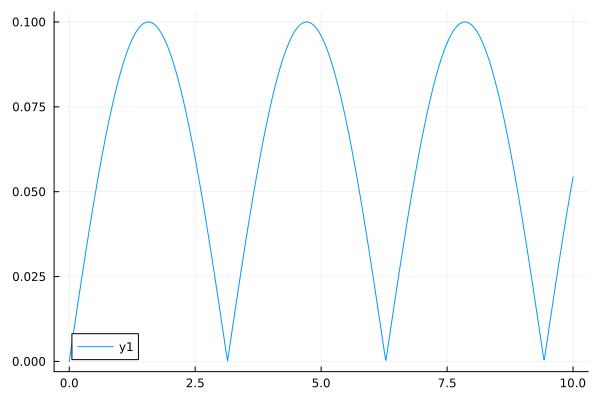

In [ ]:
using Plots
t = range(0,20,2000)

plot(t, 0.1* abs.(sin.(1 .* t)))